# 1. 벡터와 벡터의 기본 연산

## 벡터는 숫자 목록이면서 방향이다

- **배울 것**: 벡터의 모양, 덧셈·스칼라 곱, 길이, 내적, 정사영.
- 위치·속도처럼 여러 숫자로 표현되는 대상을 하나로 묶은 것이 벡터입니다. $\mathbf v=(3,4)$는 오른쪽 3, 위쪽 4만큼 움직이는 화살표로 볼 수 있습니다.
- 같은 방향과 길이의 화살표는 시작 위치가 달라도 같은 자유벡터입니다.
- NumPy의 `(3,)`은 1차원 배열입니다. `(1,3)`인 행벡터, `(3,1)`인 열벡터와 구분해야 합니다. `(3,)`에 `.T`를 붙여도 모양은 바뀌지 않습니다.

## 덧셈·길이·내적

$$
\mathbf v+\mathbf w=(v_1+w_1,\ldots,v_n+w_n),\qquad
\|\mathbf v\|_2=\sqrt{\sum_{i=1}^n v_i^2}
$$

- 덧셈은 이동을 이어 붙이는 일입니다. $(1,2)+(4,-6)=(5,-4)$입니다.
- 스칼라 곱 $a\mathbf v$는 길이를 $|a|$배로 바꿉니다. $a<0$이면 방향도 반대로 바뀝니다.
- $(3,4)$의 길이는 $\sqrt{9+16}=5$입니다. 단위벡터는 $(0.6,0.8)$입니다.

$$
\mathbf v^T\mathbf w=\sum_i v_iw_i
=\|\mathbf v\|\|\mathbf w\|\cos\theta
$$

- 내적은 두 벡터가 같은 방향을 얼마나 향하는지 측정합니다. 두 벡터가 모두 0이 아닐 때 내적 0은 직교를 뜻합니다.
- 원소별 곱 `v*w`는 벡터를, `v@w`는 1차원 벡터끼리일 때 내적 스칼라를 만듭니다.

## 정사영: 한 방향의 성분만 남기기

$$
\mathbf t_{\parallel}=\frac{\mathbf r^T\mathbf t}{\mathbf r^T\mathbf r}\mathbf r,
\qquad \mathbf t_{\perp}=\mathbf t-\mathbf t_{\parallel}
$$

- 기준 방향 $\mathbf r$은 영벡터가 아니어야 합니다. 분모는 목표 벡터가 아니라 **기준 벡터의 길이 제곱**입니다.
- $\mathbf a=(1,2),\mathbf b=(1.5,0.5)$이면 계수는 $2.5/5=0.5$, 투영은 $(0.5,1)$, 잔차는 $(1,-0.5)$입니다.
- 잔차와 기준 방향의 내적은 $1-1=0$입니다. 이 직교 조건이 최소제곱법의 출발점입니다.
- **주의**: 영벡터를 길이로 나누면 0으로 나누게 됩니다. `nan`은 새로운 방향이 생겼다는 뜻이 아니라 정규화가 정의되지 않는다는 표시입니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch01'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260926)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260926)

재현용 난수 시드: 20260926


### 코드 01-01

- 원본: `original_py/LA4DS_ch01.py` 1–9행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 벡터의 모양과 차원

### 코드 01-02

- 원본: `original_py/LA4DS_ch01.py` 11–21행.

In [3]:
# a vector as a Python list datatype
asList = [1,2,3]

# same numbers, but as a dimensionless numpy array
asArray = np.array([1,2,3])

# again same numbers, but now endowed with orientations
rowVec = np.array([ [1,2,3] ]) # row
colVec = np.array([ [1],[2],[3] ]) # column

# Note the use of spacing when defining the vectors; that is not necessary but makes the code more readable.

### 코드 01-03

- 원본: `original_py/LA4DS_ch01.py` 23–27행.

In [4]:
# Check the sizes of the variables
print(f'asList:  {np.shape(asList)}') # using np's shape function
print(f'asArray: {asArray.shape}') # using a method associated with numpy objects
print(f'rowVec:  {rowVec.shape}')
print(f'colVec:  {colVec.shape}')

asList:  (3,)
asArray: (3,)
rowVec:  (1, 3)
colVec:  (3, 1)


### 화살표로 보는 벡터

### 코드 01-04

- 원본: `original_py/LA4DS_ch01.py` 29–46행.

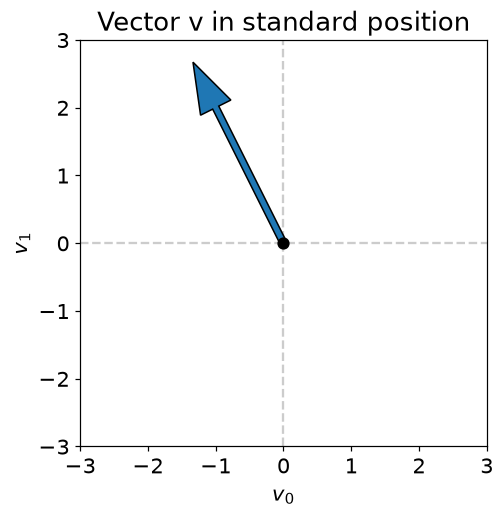

In [5]:
# create a vector
v = np.array([-1,2])

# plot that vector (and a dot for the tail)
plt.arrow(0,0,v[0],v[1],head_width=.5,width=.1)
plt.plot(0,0,'ko',markerfacecolor='k',markersize=7)

# add axis lines
plt.plot([-3,3],[0,0],'--',color=[.8,.8,.8],zorder=-1)
plt.plot([0,0],[-3,3],'--',color=[.8,.8,.8],zorder=-1)

# make the plot look nicer
plt.axis('square')
plt.axis([-3,3,-3,3])
plt.xlabel('$v_0$')
plt.ylabel('$v_1$')
plt.title('Vector v in standard position')
plt.show()

### 코드 01-05

- 원본: `original_py/LA4DS_ch01.py` 48–83행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:34: SyntaxWarning: invalid escape sequence '\m'
<ipython-input-6-e67e7fcee828>:34: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Vector $\mathbf{v}$ in various locations')


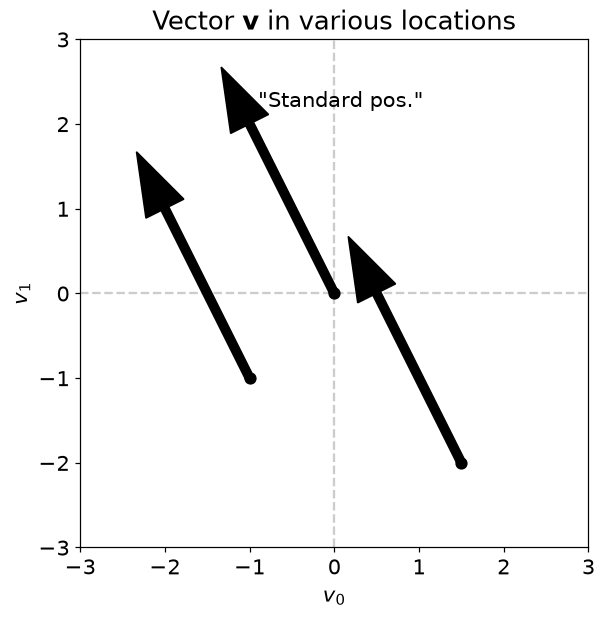

In [6]:
# A range of starting positions

startPos = [
            [0,0],
            [-1,-1],
            [1.5,-2]
            ]


# create a new figure
fig = plt.figure(figsize=(6,6))

for s in startPos:

  # plot that vector (and a dot for the tail)
  # note that plt.arrow automatically adds an offset to the third/fourth inputs
  plt.arrow(s[0],s[1],v[0],v[1],head_width=.5,width=.1,color='black')
  plt.plot(s[0],s[1],'ko',markerfacecolor='k',markersize=7)

  # indicate the vector in its standard position
  if s==[0,0]:
    plt.text(v[0]+.1,v[1]+.2,'"Standard pos."')


# add axis lines
plt.plot([-3,3],[0,0],'--',color=[.8,.8,.8],zorder=-1)
plt.plot([0,0],[-3,3],'--',color=[.8,.8,.8],zorder=-1)

# make the plot look nicer
plt.axis('square')
plt.axis([-3,3,-3,3])
plt.xlabel('$v_0$')
plt.ylabel('$v_1$')
plt.title('Vector $\mathbf{v}$ in various locations')
plt.savefig(ASSET / 'Figure_01_01.png',dpi=140) # write out the fig to a file
plt.show()

### 벡터 덧셈

### 코드 01-06

- 원본: `original_py/LA4DS_ch01.py` 85–96행.

In [7]:
# Using 2D vectors here instead of 3D vectors in the book to facilitate visualization
v = np.array([1,2])
w = np.array([4,-6])
vPlusW = v+w

# print out all three vectors
print(v)
print(w)
print(vPlusW)

# Note that here we don't need to worry about vector orientation (row vs. column), 
# so for simplicity the vectors are created orientationless.

[1 2]
[ 4 -6]
[ 5 -4]


### 코드 01-07

- 원본: `original_py/LA4DS_ch01.py` 98–99행.

In [8]:
# Where's the code to generate Figure 2-2? 
# It's exercise 0!

### 벡터 뺄셈

### 코드 01-08

- 원본: `original_py/LA4DS_ch01.py` 101–107행.

In [9]:
# Same v and w as above for comparison
vMinusW = v-w

# print out all three vectors
print(v)
print(w)
print(vMinusW)

[1 2]
[ 4 -6]
[-3  8]


### 코드 01-09

- 원본: `original_py/LA4DS_ch01.py` 109–109행.

In [10]:
# Code for Figure 2-2 is part of Exercise 0.

### 스칼라 곱과 방향

### 코드 01-10

- 원본: `original_py/LA4DS_ch01.py` 111–120행.

In [11]:
# a scalar
s = -1/2

# a vector
b = np.array([3,4])

# print them
print(b*s)

# Question: Does vector b need to be a numpy array? What happens if it's a list?

[-1.5 -2. ]


### 코드 01-11

- 원본: `original_py/LA4DS_ch01.py` 122–126행.

In [12]:
# Scalar-vector addition
s = 3.5

print(v)
print(s+v)

[1 2]
[4.5 5.5]


### 코드 01-12

- 원본: `original_py/LA4DS_ch01.py` 128–136행.

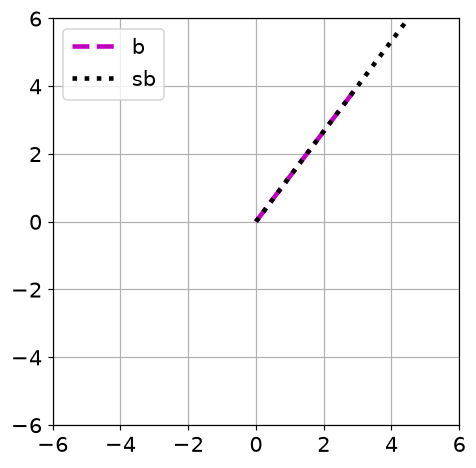

In [13]:
# plot
plt.plot([0,b[0]],[0,b[1]],'m--',linewidth=3,label='b')
plt.plot([0,s*b[0]],[0,s*b[1]],'k:',linewidth=3,label='sb')

plt.grid()
plt.axis('square')
plt.axis([-6,6,-6,6])
plt.legend()
plt.show()

### 코드 01-13

- 원본: `original_py/LA4DS_ch01.py` 138–166행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:24: SyntaxWarning: invalid escape sequence '\s'
<ipython-input-14-f80b7cc42330>:24: SyntaxWarning: invalid escape sequence '\s'
  axs[i].set_title(f'$\sigma$ = {s:.2f}')


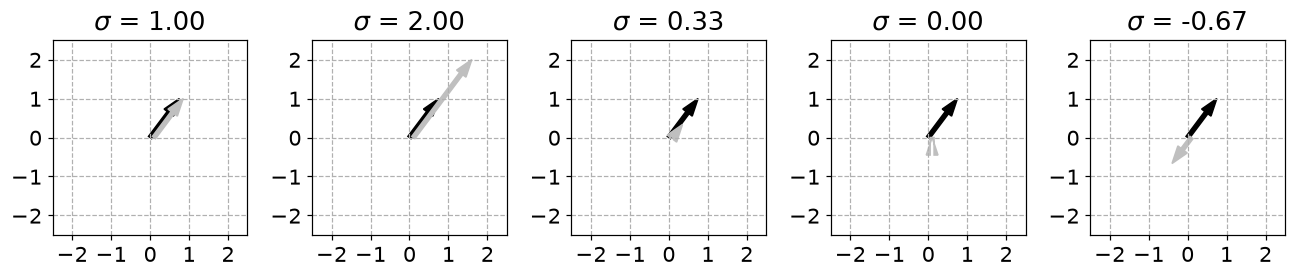

In [14]:
# Effects of different scalars

# a list of scalars:
scalars = [ 1, 2, 1/3, 0, -2/3 ]

baseVector = np.array([ .75,1 ])

# create a figure
fig,axs = plt.subplots(1,len(scalars),figsize=(12,3))
i = 0 # axis counter

for s in scalars:

  # compute the scaled vector
  v = s*baseVector

  # plot it
  axs[i].arrow(0,0,baseVector[0],baseVector[1],head_width=.3,width=.1,color='k',length_includes_head=True)
  axs[i].arrow(.1,0,v[0],v[1],head_width=.3,width=.1,color=[.75,.75,.75],length_includes_head=True)
  axs[i].grid(linestyle='--')
  axs[i].axis('square')
  axs[i].axis([-2.5,2.5,-2.5,2.5])
  axs[i].set(xticks=np.arange(-2,3), yticks=np.arange(-2,3))
  axs[i].set_title(f'$\sigma$ = {s:.2f}')
  i+=1 # update axis counter

plt.tight_layout()
plt.savefig(ASSET / 'Figure_01_03.png',dpi=140)
plt.show()

### 행·열과 전치

### 코드 01-14

- 원본: `original_py/LA4DS_ch01.py` 169–173행.

In [15]:
# Row vector
r = np.array([ [1,2,3] ])

# orientationless array
l = np.array([1,2,3])

### 코드 01-15

- 원본: `original_py/LA4DS_ch01.py` 175–182행.

In [16]:
# print out the vector, its transpose, and its double-transpose
print(r), print(' ')

# Transpose the row vector
print(r.T), print(' ')

# double-transpose
print(r.T.T)

[[1 2 3]]
 
[[1]
 [2]
 [3]]
 
[[1 2 3]]


### 코드 01-16

- 원본: `original_py/LA4DS_ch01.py` 184–187행.

In [17]:
# Same for the orientationless array
print(l), print(' ')
print(l.T), print(' ')
print(l.T.T)

[1 2 3]
 
[1 2 3]
 
[1 2 3]


### 내적의 분배법칙

### 코드 01-17

- 원본: `original_py/LA4DS_ch01.py` 191–201행.

In [18]:
# just some random vectors...
v = np.array([ 0,1,2 ])
w = np.array([ 3,5,8 ])
u = np.array([ 13,21,34 ])

# two ways to comptue
res1 = np.dot( v, w+u )
res2 = np.dot( v,w ) + np.dot( v,u )

# show that they are equivalent
res1,res2

Out[18]: (np.int64(110), np.int64(110))


## 연습문제 1 · 덧셈과 뺄셈을 화살표로 확인하기

- **목표**: $(1,2)$와 $(4,-6)$의 합·차를 좌표와 그림으로 연결합니다.
- **풀이 순서**: 성분끼리 더해 $(5,-4)$, 빼서 $(-3,8)$을 구합니다. 두 번째 화살표를 첫 번째 끝으로 평행이동해 이어 붙입니다.
- **결과 해석**: 합은 이동을 합친 결과입니다. 뺄셈은 $-w$를 더하는 것이므로 두 번째 화살표의 방향이 반대가 됩니다.

### 코드 01-18

- 원본: `original_py/LA4DS_ch01.py` 205–226행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:20: SyntaxWarning: invalid escape sequence '\m'
<ipython-input-19-9e56ef897133>:20: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Vectors $\mathbf{v}$, $\mathbf{w}$, and $\mathbf{v+w}$')


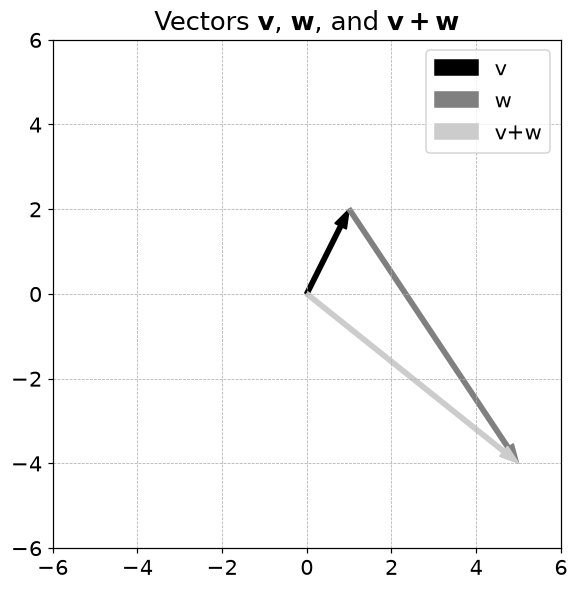

In [19]:
# The vectors
v = np.array([1,2])
w = np.array([4,-6])
vPlusW = v+w


# now plot all three vectors
plt.figure(figsize=(6,6))

a1 = plt.arrow(0,0,v[0],v[1],head_width=.3,width=.1,color='k',length_includes_head=True)
a2 = plt.arrow(v[0],v[1],w[0],w[1],head_width=.3,width=.1,color=[.5,.5,.5],length_includes_head=True)
a3 = plt.arrow(0,0,vPlusW[0],vPlusW[1],head_width=.3,width=.1,color=[.8,.8,.8],length_includes_head=True)


# make the plot look a bit nicer
plt.grid(linestyle='--',linewidth=.5)
plt.axis('square')
plt.axis([-6,6,-6,6])
plt.legend([a1,a2,a3],['v','w','v+w'])
plt.title('Vectors $\mathbf{v}$, $\mathbf{w}$, and $\mathbf{v+w}$')
plt.savefig(ASSET / 'Figure_01_02a.png',dpi=140) # write out the fig to a file
plt.show()

### 코드 01-19

- 원본: `original_py/LA4DS_ch01.py` 228–247행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:18: SyntaxWarning: invalid escape sequence '\m'
<ipython-input-20-f54ec9eda9f9>:18: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Vectors $\mathbf{v}$, $\mathbf{w}$, and $\mathbf{v-w}$')


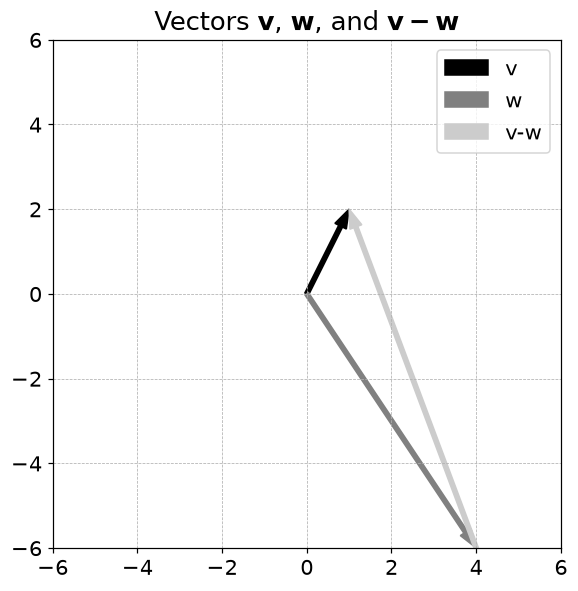

In [20]:
# vector difference
vMinusW = v-w


# now plot all three vectors
plt.figure(figsize=(6,6))

a1 = plt.arrow(0,0,v[0],v[1],head_width=.3,width=.1,color='k',length_includes_head=True)
a2 = plt.arrow(0,0,w[0],w[1],head_width=.3,width=.1,color=[.5,.5,.5],length_includes_head=True)
a3 = plt.arrow(w[0],w[1],vMinusW[0],vMinusW[1],head_width=.3,width=.1,color=[.8,.8,.8],length_includes_head=True)


# make the plot look a bit nicer
plt.grid(linestyle='--',linewidth=.5)
plt.axis('square')
plt.axis([-6,6,-6,6])
plt.legend([a1,a2,a3],['v','w','v-w'])
plt.title('Vectors $\mathbf{v}$, $\mathbf{w}$, and $\mathbf{v-w}$')
plt.savefig(ASSET / 'Figure_01_02b.png',dpi=140)
plt.show()

## 연습문제 2 · 노름 함수 직접 만들기

- **목표**: 벡터 길이를 라이브러리 없이 계산합니다.
- **풀이 순서**: 각 성분을 제곱하고 합한 뒤 제곱근을 취합니다. 단위벡터와 $(1,2,3)$으로 만든 함수를 `np.linalg.norm`과 비교합니다.
- **결과 해석**: 단위벡터는 1, $(1,2,3)$은 $\sqrt{14}\approx3.741657$입니다. 원본 함수는 실수 벡터를 가정합니다. 복소수는 절댓값 제곱이 필요합니다.

### 코드 01-20

- 원본: `original_py/LA4DS_ch01.py` 252–262행.

In [21]:
# the function
def normOfVect(v):
  return np.sqrt(np.sum(v**2))

# test it on a unit-norm vector
w = np.array([0,0,1])
print( normOfVect(w) )

# non-unit-norm vector, and confirm using np.linalg.norm
w = np.array([1,2,3])
print( normOfVect(w),np.linalg.norm(w) )

1.0
3.7416573867739413 3.7416573867739413


## 연습문제 3 · 단위벡터와 영벡터

- **목표**: 방향을 유지하며 길이만 1로 맞춥니다.
- **풀이 순서**: 벡터를 원래 노름으로 나누고 새 노름을 확인합니다. 마지막에는 영벡터를 넣어 분모가 0인 상황을 관찰합니다.
- **결과 해석**: 정상 입력은 새 노름이 1입니다. 영벡터 결과 `nan`과 경고는 정규화가 정의되지 않음을 보여 줍니다. 실제 함수는 노름 0을 검사해 예외를 내야 합니다.

### 코드 01-21

- 원본: `original_py/LA4DS_ch01.py` 267–292행.

In [22]:
# define function
def createUnitVector(v):
  # get vector norm
  mu = np.linalg.norm(v)
  # return unit vector
  return v / mu


# test on a unit vector
w = np.array([0,1,0])
print( createUnitVector(w) )

# test on a non-unit vector that is easy to confirm
w = np.array([0,3,0])
print( createUnitVector(w) )

# test on a non-unit vector
w = np.array([13,-5,7])
uw = createUnitVector(w)
print( uw ), print(' ')
# confirm the vectors' norms
print( np.linalg.norm(w),np.linalg.norm(uw) )

# what happens with the zeros vector?
print('\n\n\n') # just some spaces
createUnitVector( np.zeros((4,1)) )

[0. 1. 0.]
[0. 1. 0.]
[ 0.83395 -0.32075  0.44905]
 
15.588457268119896 0.9999999999999999




Out[22]: 
array([[nan],
       [nan],
       [nan],
       [nan]])


<ipython-input-22-57a0ea52dbd0>:6: RuntimeWarning: invalid value encountered in divide
  return v / mu


## 연습문제 4 · 원하는 길이로 바꾸기

- **목표**: 벡터 방향을 유지하면서 목표 길이 mag를 부여합니다.
- **풀이 순서**: 먼저 $v/\|v\|$로 정규화한 뒤 mag를 곱합니다. $(1,0,0)$과 임의 벡터를 사용해 전후 길이를 비교합니다.
- **결과 해석**: mag가 양수이면 길이는 mag입니다. 음수라면 실제 길이는 $|mag|$이고 방향도 뒤집힙니다. 영벡터는 별도 처리가 필요합니다.

### 코드 01-22

- 원본: `original_py/LA4DS_ch01.py` 296–309행.

In [23]:
# define the function
def createMagVector(v,mag):
  # get vector norm
  mu = np.linalg.norm(v)
  # return unit vector
  return mag * v / mu

# test on a vector that is easy to confirm
w = np.array([1,0,0])
mw = createMagVector(w,4)
print( mw )

# confirm the vectors' norms
print( np.linalg.norm(w),np.linalg.norm(mw) )

[4. 0. 0.]
1.0 4.0


## 연습문제 5 · 전치 구현하기

- **목표**: 행벡터의 성분을 열벡터로 옮기는 규칙을 이해합니다.
- **풀이 순서**: `(1,3)` 배열과 `(3,1)` 영배열을 만들고 `vt[i,0]=v[0,i]`로 복사합니다. `.T` 결과와 비교합니다.
- **결과 해석**: 숫자는 같고 모양만 바뀝니다. `zeros` 기본 dtype 때문에 정수가 실수로 표시될 수 있습니다. 값의 일치와 dtype 일치는 구분합니다.

### 코드 01-23

- 원본: `original_py/LA4DS_ch01.py` 314–331행.

In [24]:
# the row vector to transpose
v = np.array([[1,2,3]])

# initialize the column vector
vt = np.zeros((3,1))

# direct implementation of the formula using a for loop
for i in range(v.shape[1]):
  vt[i,0] = v[0,i]

# confirm!
print(v), print(' ')
print(vt)

# Note about data types: The two vectors actually have different data types
#  (ints vs. floats). That happened because I defined v using ints while the default type
#  for np.zeros is float. You can match data types in several ways, including: 
#  (1) write 3. instead of 3 when creating v; (2) use dtype=np.float as an optional input.

[[1 2 3]]
 
[[1.]
 [2.]
 [3.]]


## 연습문제 6 · 자기 내적과 길이 제곱

- **목표**: $v^Tv=\|v\|^2$를 확인합니다.
- **풀이 순서**: 난수 벡터의 자기 내적과 직접 만든 노름 함수의 제곱을 각각 구합니다.
- **결과 해석**: 두 수는 반올림 오차 범위에서 같습니다. 제곱근을 취하기 전 합과 내적이 같은 연산이기 때문입니다.

### 코드 01-24

- 원본: `original_py/LA4DS_ch01.py` 335–346행.

In [25]:
# some vector
c = np.random.randn(5)

# squared norm as dot product with itself
sqrNrm1 = np.dot(c,c)

# squared norm via our function from exercise 1
sqrNrm2 = normOfVect(c)**2

# print both to confirm they're the same
print( sqrNrm1 )
print( sqrNrm2 )

4.235835462331126
4.235835462331127


## 연습문제 7 · 실수 내적의 교환법칙

- **목표**: $a^Tb=b^Ta$를 수치로 검증합니다.
- **풀이 순서**: 열벡터 두 개를 만들고 원소별 곱의 합을 양쪽 순서로 계산합니다. 두 결과의 차이를 출력합니다.
- **결과 해석**: 차이는 0입니다. `(n,1)` 배열끼리 `np.dot(a,b)`는 차원이 맞지 않습니다. `a.T@b` 또는 펼친 벡터를 사용해야 합니다.

### 코드 01-25

- 원본: `original_py/LA4DS_ch01.py` 350–364행.

In [26]:
# dimensionality
n = 11

# some random column vectors
a = np.random.randn(n,1)
b = np.random.randn(n,1)

# dot products both ways
atb = np.sum(a*b)
bta = np.sum(b*a)

# they're equal if their difference is 0
atb - bta

# For an extra challenge, see what happens when you use np.dot() to compute the dot products.

Out[26]: np.float64(0.0)


## 연습문제 8 · 투영 계수 구하기

- **목표**: b에서 a방향 성분과 수직 성분을 분리합니다.
- **풀이 순서**: $\beta=(a^Tb)/(a^Ta)$를 구하고 $\beta a$를 그립니다. 나머지 $b-\beta a$를 계산합니다.
- **결과 해석**: 이 예제의 계수는 0.5, 평행 성분은 $(0.5,1)$입니다. 원본 변수 `projvect`는 이름과 달리 수직 잔차를 담고 있으므로 혼동하지 마세요.

### 코드 01-26

- 원본: `original_py/LA4DS_ch01.py` 366–403행.

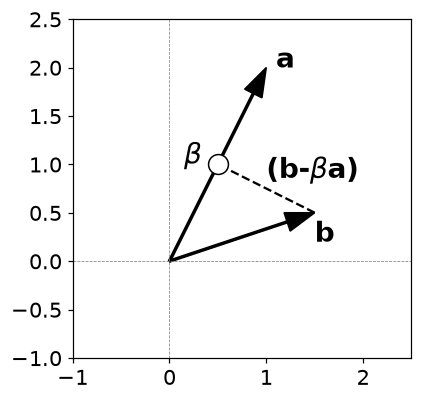

In [27]:
# the vectors a and b
a = np.array([1,2])
b = np.array([1.5,.5])

# compute beta
beta = np.dot(a,b) / np.dot(a,a)

# compute the projection vector (not explicitly used in the plot)
projvect = b - beta*a


# draw the figure
plt.figure(figsize=(4,4))

# vectors
plt.arrow(0,0,a[0],a[1],head_width=.2,width=.02,color='k',length_includes_head=True)
plt.arrow(0,0,b[0],b[1],head_width=.2,width=.02,color='k',length_includes_head=True)

# projection vector
plt.plot([b[0],beta*a[0]],[b[1],beta*a[1]],'k--')

# projection on a
plt.plot(beta*a[0],beta*a[1],'ko',markerfacecolor='w',markersize=13)

# make the plot look nicer
plt.plot([-1,2.5],[0,0],'--',color='gray',linewidth=.5)
plt.plot([0,0],[-1,2.5],'--',color='gray',linewidth=.5)

# add labels
plt.text(a[0]+.1,a[1],'a',fontweight='bold',fontsize=18)
plt.text(b[0],b[1]-.3,'b',fontweight='bold',fontsize=18)
plt.text(beta*a[0]-.35,beta*a[1],r'$\beta$',fontweight='bold',fontsize=18)
plt.text((b[0]+beta*a[0])/2,(b[1]+beta*a[1])/2+.1,r'(b-$\beta$a)',fontweight='bold',fontsize=18)

# some finishing touches
plt.axis('square')
plt.axis([-1,2.5,-1,2.5])
plt.show()

## 연습문제 9 · 직교 분해 검증하기

- **목표**: 평행 성분과 수직 성분이 목표 벡터를 복원하는지 확인합니다.
- **풀이 순서**: 기준 r로 t를 투영하고 잔차를 구합니다. 두 성분의 합과 목표의 차이, 두 성분의 내적을 확인한 뒤 함께 그립니다.
- **결과 해석**: 합의 오차와 내적이 0 근처이면 분해가 맞습니다. 그림에서 직각처럼 보이는 것보다 이 수치 검증이 확실합니다.

### 코드 01-27

- 원본: `original_py/LA4DS_ch01.py` 407–440행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

[-1.17273  -1.231792]
[-1.17273  -1.231792]
0.0


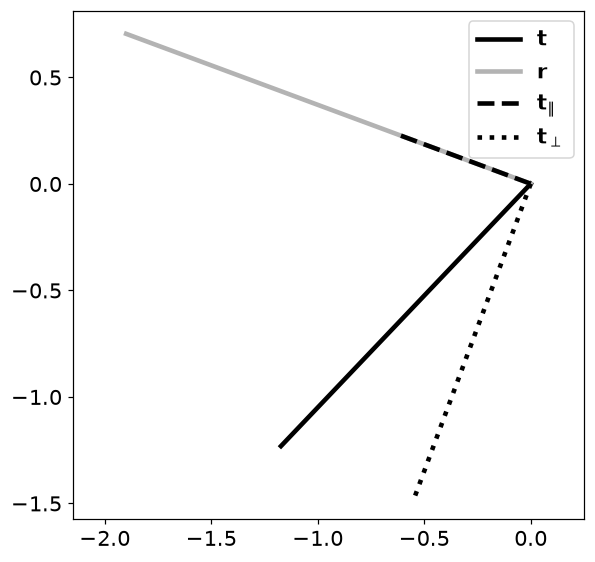

In [28]:
# generate random R2 vectors (note: no orientation here! we don't need it for this exercise)
t = np.random.randn(2)
r = np.random.randn(2)

# the decomposition
t_para = r * (np.dot(t,r) / np.dot(r,r))
t_perp = t - t_para

# confirm that the two components sum to the target
print(t)
print( t_para+t_perp )

# confirm orthogonality (dot product must be zero!)
print( np.dot(t_para,t_perp) )
# Note about this result: Due to numerical precision errors, 
#   you might get a result of something like 10^-17, which can be interpretd as zero.



# draw them!
plt.figure(figsize=(6,6))

# draw main vectors
plt.plot([0,t[0]],[0,t[1]],color='k',linewidth=3,label=r'$\mathbf{t}$')
plt.plot([0,r[0]],[0,r[1]],color=[.7,.7,.7],linewidth=3,label=r'$\mathbf{r}$')

# draw decomposed vector components
plt.plot([0,t_para[0]],[0,t_para[1]],'k--',linewidth=3,label=r'$\mathbf{t}_{\|}$')
plt.plot([0,t_perp[0]],[0,t_perp[1]],'k:',linewidth=3,label=r'$\mathbf{t}_{\perp}$')

plt.axis('equal')
plt.legend()
plt.savefig(ASSET / 'Figure_01_08.png',dpi=140)
plt.show()

## 연습문제 10 · 잘못된 분모의 영향

- **목표**: 투영 공식의 분모가 왜 기준 벡터의 제곱 노름인지 설명합니다.
- **풀이 순서**: 분모를 $t^Tt$로 바꾼 뒤 잔차를 다시 계산하고 r과의 내적을 비교합니다. 원본 한 줄 뒤에 추가 검증을 제공합니다.
- **결과 해석**: 합은 정의상 여전히 t가 되지만 직교는 일반적으로 깨집니다. ‘합이 맞음’만으로 정사영을 검증할 수 없다는 예제입니다.

### 코드 01-28

- 원본: `original_py/LA4DS_ch01.py` 442–443행.
- **보완**: 원본에 없던 독립 실행·검증 코드를 추가했습니다.

In [29]:
# Replace t_para in the previous exercise with the line below:
t_para = r * (np.dot(t,r) / np.dot(t,t))

# 추가 검증: 합은 맞아도 직교가 깨질 수 있다.
t_perp_wrong = t - t_para
t_para_correct = r * (t @ r) / (r @ r)
print('잘못된 분모의 직교 잔차:', r @ t_perp_wrong)
print('올바른 분모의 직교 잔차:', r @ (t-t_para_correct))
assert np.allclose(r @ (t-t_para_correct), 0)


잘못된 분모의 직교 잔차: -0.5698074110429017
올바른 분모의 직교 잔차: 0.0


## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [30]:
_v=np.array([3.,4.]); _a=np.array([1.,2.]); _b=np.array([1.5,.5])
_p=_a*(_a@_b)/(_a@_a); _e=_b-_p
print('길이:',np.linalg.norm(_v),'단위벡터:',_v/np.linalg.norm(_v))
print('투영:',_p,'잔차:',_e,'직교 내적:',_a@_e)
assert np.allclose(_p,[.5,1]) and np.allclose(_a@_e,0)


길이: 5.0 단위벡터: [0.6 0.8]
투영: [0.5 1. ] 잔차: [ 1.  -0.5] 직교 내적: 0.0
